# 07 — SpatialData visualization (interactive)
Choose an Approach-II variant, inspect coordinate/filled-segmentation/outline views, and interactively tune gene-transcript overlay parameters.

In [2]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("raw data exists    :", RAW_DIR.exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [3]:
import spatialdata as sd
import spatialdata_plot
from config.markers import MARKER_PANEL

# ============================================================
# Select saved rule variant and spatial object — EDIT HERE
# ============================================================
RULE_RUN_TAG = "min3"
variant_dir = RESULTS_DIR / "FOV46" / "approach_ii_variants" / RULE_RUN_TAG
IN = variant_dir / f"GSM9046088_FOV46_approach_i_ii_{RULE_RUN_TAG}.h5ad"
S46_PATH = SPATIAL_DIR / "GSM9046088_CosMx_FOV46.zarr"

print("AnnData input :", IN, "exists=", IN.exists())
print("Spatial input :", S46_PATH, "exists=", S46_PATH.exists())
if not IN.exists(): raise FileNotFoundError(IN)
if not S46_PATH.exists(): raise FileNotFoundError(S46_PATH)

a = sc.read_h5ad(IN)
S46 = sd.read_zarr(S46_PATH)
print("Loaded SpatialData safely (without print(S46))")
print("points:", list(S46.points))
print("shapes:", list(S46.shapes))
print("tables:", list(S46.tables))


AnnData input : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3/GSM9046088_FOV46_approach_i_ii_min3.h5ad exists= True
Spatial input : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/data/spatial/GSM9046088_CosMx_FOV46.zarr exists= True
Loaded SpatialData safely (without print(S46))
points: ['transcripts']
shapes: ['cell_boundaries']
tables: ['table']


## A. Coordinate spatial annotation
Change `ANNOTATION_COL` to Approach I, your selected Approach-II variant, or `final_CT`.

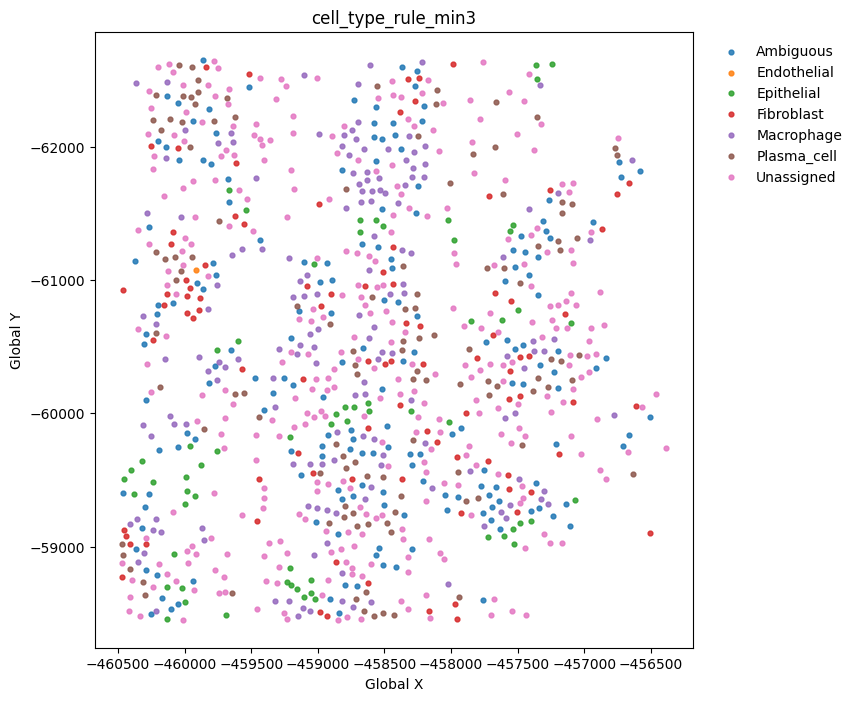

In [4]:
ANNOTATION_COL=f"cell_type_rule_{RULE_RUN_TAG}"  # or "cell_type_scanpy" / "final_CT"
xy=np.asarray(a.obsm["spatial"]); lab=a.obs[ANNOTATION_COL].astype("category")
fig,ax=plt.subplots(figsize=(8,8))
for cat in lab.cat.categories:
    m=lab.astype(str).to_numpy()==str(cat);ax.scatter(xy[m,0],xy[m,1],s=12,label=str(cat),alpha=.85)
ax.set_aspect("equal");ax.invert_yaxis();ax.set_xlabel("Global X");ax.set_ylabel("Global Y");ax.set_title(ANNOTATION_COL)
ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False);plt.show()

## B. Filled cell-segmentation polygons
The annotation is copied into the SpatialData table by matching cell IDs.

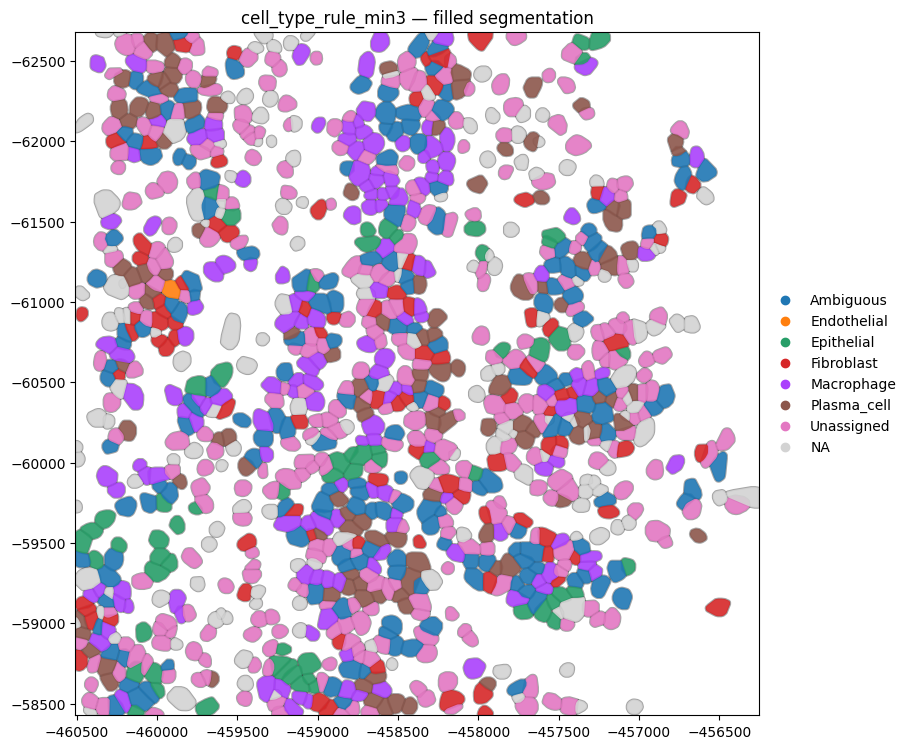

In [5]:
table=S46["table"]
common=table.obs_names.intersection(a.obs_names)
aligned=pd.Series(pd.NA,index=table.obs_names,dtype="object")
aligned.loc[common]=a.obs.loc[common,ANNOTATION_COL].astype(str).to_numpy()
categories=list(pd.unique(a.obs[ANNOTATION_COL].astype(str)))
table.obs[ANNOTATION_COL]=pd.Categorical(aligned,categories=categories)

S46.pl.render_shapes(
    element="cell_boundaries",color=ANNOTATION_COL,fill_alpha=.9,outline_alpha=.35,outline_color="black"
).pl.show(coordinate_systems="global",figsize=(9,9),title=f"{ANNOTATION_COL} — filled segmentation")

## C. White cell-boundary outlines + annotation-colored centers
This emphasizes segmentation geometry without filling the cells.

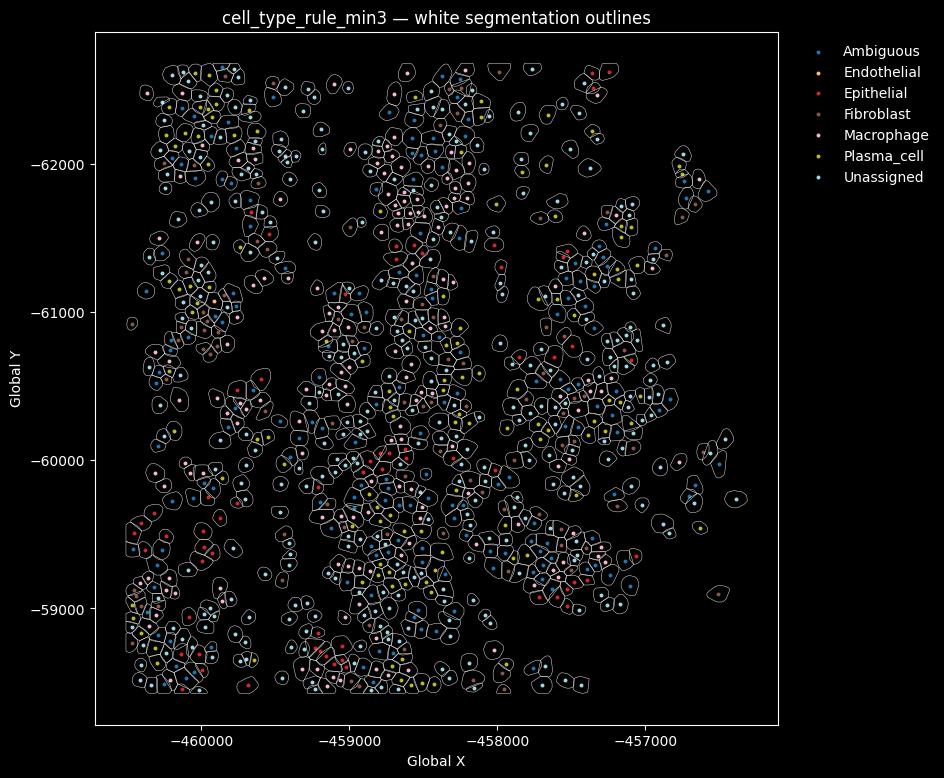

In [6]:
shapes=S46["cell_boundaries"]
common=shapes.index.intersection(a.obs_names)
sh=shapes.loc[common]; vals=a.obs.loc[common,ANNOTATION_COL].astype("category")
pos=pd.DataFrame({"x":xy[:,0],"y":xy[:,1]},index=a.obs_names).loc[common]
fig,ax=plt.subplots(figsize=(9,9));fig.patch.set_facecolor("black");ax.set_facecolor("black")
sh.boundary.plot(ax=ax,color="white",linewidth=.35,alpha=.9)
cmap=plt.get_cmap("tab20",max(len(vals.cat.categories),1))
for i,cat in enumerate(vals.cat.categories):
    m=vals.astype(str).to_numpy()==str(cat)
    ax.scatter(pos.loc[m,"x"],pos.loc[m,"y"],s=8,color=cmap(i),label=str(cat),linewidths=0)
ax.set_aspect("equal");ax.invert_yaxis();ax.set_xlabel("Global X",color="white");ax.set_ylabel("Global Y",color="white");ax.tick_params(colors="white")
for sp in ax.spines.values():sp.set_color("white")
ax.set_title(f"{ANNOTATION_COL} — white segmentation outlines",color="white")
leg=ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False);plt.setp(leg.get_texts(),color="white")
plt.show()

## D. Interactive gene + segmentation + transcript molecules
Edit `GENE`, point size/alpha, and polygon alpha, then rerun this cell. No figure is automatically closed.

/home/jqu/.conda/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/jqu/.conda/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/jqu/.conda/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


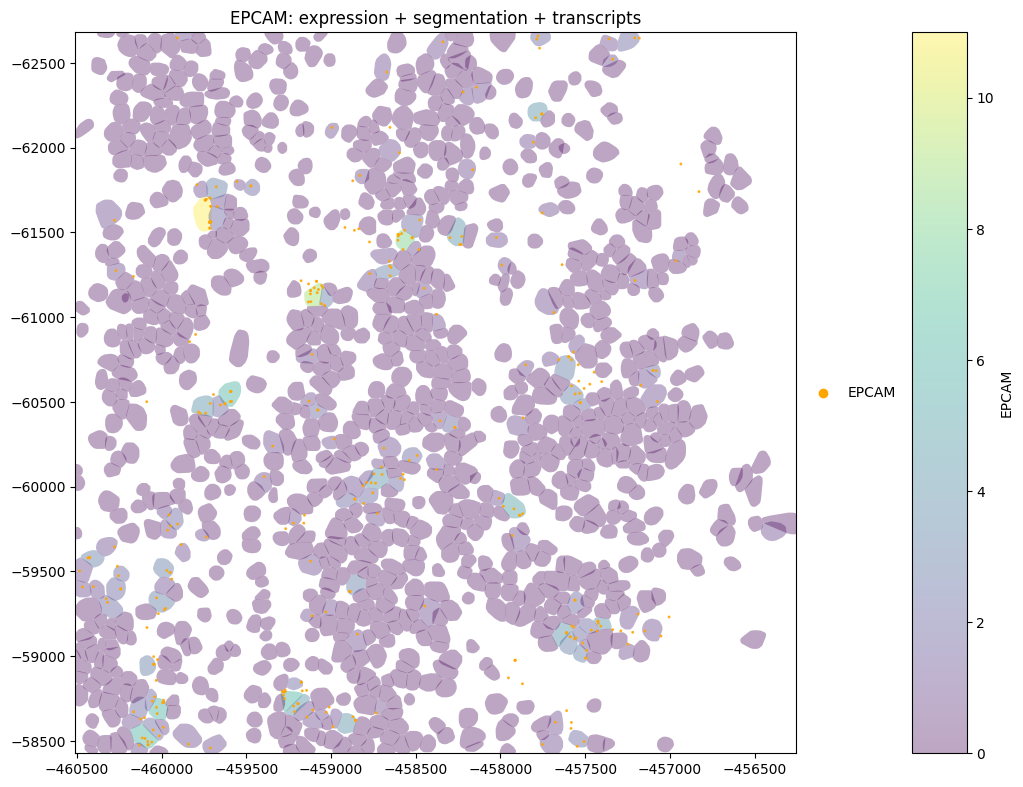

In [7]:
GENE="EPCAM"
POINT_SIZE=1.0
POINT_ALPHA=0.55
FILL_ALPHA=0.35
OUTLINE_ALPHA=0.8

if GENE not in S46["table"].var_names:
    raise KeyError(f"{GENE} not in CosMx panel")

(
    S46.pl.render_shapes(
        element="cell_boundaries",color=GENE,fill_alpha=FILL_ALPHA,
        outline_alpha=OUTLINE_ALPHA,outline_color="white",
    )
    .pl.render_points(
        element="transcripts",color="target",groups=GENE,size=POINT_SIZE,
        alpha=POINT_ALPHA,palette="orange",method="matplotlib",
    )
    .pl.show(
        coordinate_systems="global",figsize=(9,9),
        title=f"{GENE}: expression + segmentation + transcripts",
    )
)

### Optional ipywidgets control
Run this only if `ipywidgets` is available in your Jupyter environment.

In [8]:
try:
    from ipywidgets import interact, Dropdown, FloatSlider
    genes=[g for g in ["EPCAM","KRT8","CD3D","MS4A1","C1QA","PECAM1","COL1A1","RGS5"] if g in S46["table"].var_names]
    @interact(
        gene=Dropdown(options=genes,value=genes[0]),
        point_size=FloatSlider(min=.2,max=3,step=.2,value=1),
        point_alpha=FloatSlider(min=.1,max=1,step=.1,value=.6),
        fill_alpha=FloatSlider(min=0,max=1,step=.1,value=.4),
    )
    def gene_overlay_widget(gene,point_size,point_alpha,fill_alpha):
        (S46.pl.render_shapes(element="cell_boundaries",color=gene,fill_alpha=fill_alpha,outline_alpha=.8,outline_color="white")
         .pl.render_points(element="transcripts",color="target",groups=gene,size=point_size,alpha=point_alpha,palette="orange",method="matplotlib")
         .pl.show(coordinate_systems="global",figsize=(9,9),title=gene))
except ImportError:
    print("ipywidgets is not installed; use the parameter cell above instead.")

interactive(children=(Dropdown(description='gene', options=('EPCAM', 'KRT8', 'CD3D', 'MS4A1', 'C1QA', 'PECAM1'…

## Optional versioned figure export

Interactive figures are shown inline by default. When a view is satisfactory, set `SAVE_SPATIAL_FIGURE=True` and rerun the export cell. The filename includes the rule variant, annotation column, and a custom plot tag so experiments do not overwrite one another.


In [10]:
SAVE_SPATIAL_FIGURE = True
SPATIAL_PLOT_TAG = "gene_overlay_testA"
SPATIAL_OUTPUT_DIR = variant_dir / "spatial_variants" / SPATIAL_PLOT_TAG
SPATIAL_OUTPUT_FILE = SPATIAL_OUTPUT_DIR / f"{ANNOTATION_COL}_{RULE_RUN_TAG}_{SPATIAL_PLOT_TAG}.png"

print("SAVE_SPATIAL_FIGURE:", SAVE_SPATIAL_FIGURE)
print("SPATIAL_PLOT_TAG    :", SPATIAL_PLOT_TAG)
print("Output directory    :", SPATIAL_OUTPUT_DIR)
print("Output filename     :", SPATIAL_OUTPUT_FILE.name)
print("Full output path    :", SPATIAL_OUTPUT_FILE)
print("Currently exists    :", SPATIAL_OUTPUT_FILE.exists())

if SAVE_SPATIAL_FIGURE:
    SPATIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.gcf().savefig(SPATIAL_OUTPUT_FILE, dpi=250, bbox_inches="tight")
    print("Saved:", SPATIAL_OUTPUT_FILE)
else:
    print("SAVE_SPATIAL_FIGURE=False — current figure is inline only.")


SAVE_SPATIAL_FIGURE: True
SPATIAL_PLOT_TAG    : gene_overlay_testA
Output directory    : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3/spatial_variants/gene_overlay_testA
Output filename     : cell_type_rule_min3_min3_gene_overlay_testA.png
Full output path    : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3/spatial_variants/gene_overlay_testA/cell_type_rule_min3_min3_gene_overlay_testA.png
Currently exists    : False
Saved: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3/spatial_variants/gene_overlay_testA/cell_type_rule_min3_min3_gene_overlay_testA.png


<Figure size 640x480 with 0 Axes>